# Differential Gene Expression Analysis

In this tutorial, we load and use the results saved after clustering in `spatial_notebook.ipynb`.

## VisiumHD

In [ ]:
from stLENS import stLENS
stlens = stLENS()

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data

In [ ]:
adata_stlens = sc.read_h5ad('./output/visiumhd/stlens_adata')
adata_scanpy = sc.read_h5ad('./output/visiumhd/scanpy_adata')

### DEA

In [ ]:
sc.pp.normalize_total(adata_stlens)
sc.pp.log1p(adata_stlens)

In [ ]:
import scanpy as sc

def top10_markers(adata, groupby, target, method="wilcoxon", key="deg"):
    sc.tl.rank_genes_groups(
        stlens,
        groupby=groupby,
        groups=[target],
        reference="rest",
        method=method,
        use_raw=False,     
        key_added=key,
    )
    df = sc.get.rank_genes_groups_df(adata, group=target, key=key)
    df = df.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False])
    return df[["names", "logfoldchanges", "pvals_adj", "scores"]].head(3)

#### Profib (Proliferating Fibroblast)

In [ ]:
target_name = "Proliferating Fibroblast"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['COL3A1',
 'COL1A1',
 'COL1A2',
 'SPARC',
 'VIM',
 'MT-ND4',
 'MT-CYB',
 'MT-CO3',
 'MT-ATP6',
 'MT-ND4L']

In [ ]:
mask_st = adata_stlens.obs["leiden_5.0"].astype(str) == "33"
mask_sc = adata_scanpy.obs["leiden_4.5"].astype(str) == "32"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/101406530.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


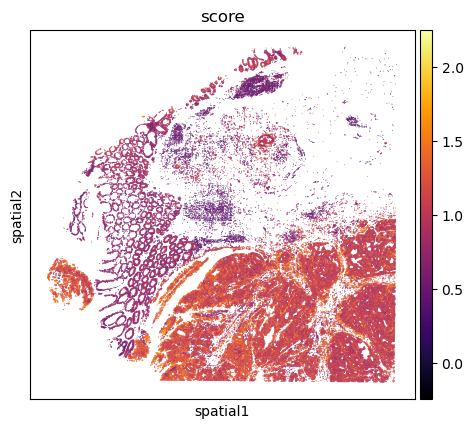

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,  
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_profib.pdf", bbox_inches="tight")

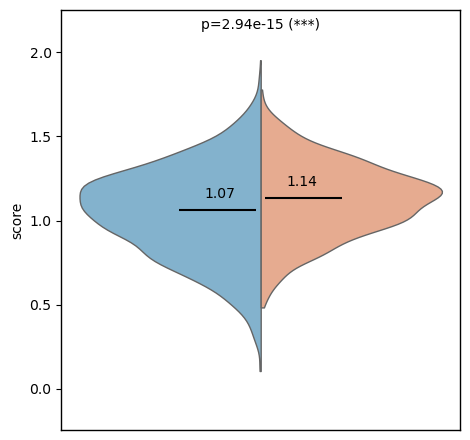

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_profib.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Goblet

In [ ]:
target_name = "Goblet"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['ITLN1',
 'MUC5B',
 'SPINK4',
 'MUC2',
 'REG4',
 'LEFTY1',
 'PIGR',
 'WFDC2',
 'FCGBP',
 'PLA2G2A']

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "2"
mask_sc = adata_scanpy.obs["leiden_0.5"].astype(str) == "3"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/915960531.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


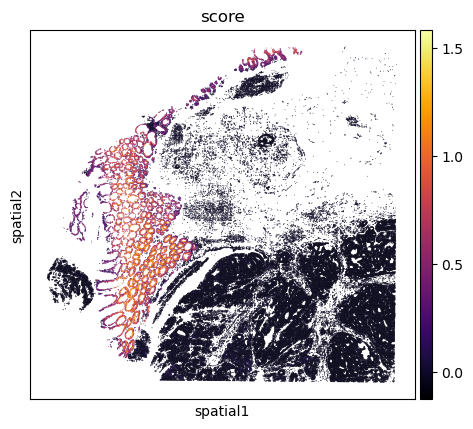

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)


cax = fig.axes[-1]


cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_goblet.pdf", bbox_inches="tight")

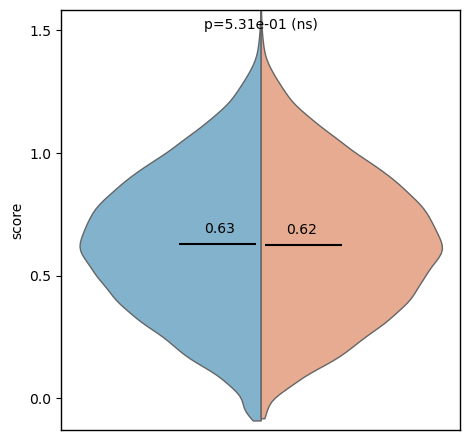

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_goblet.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Entero (Enterocyte)

In [ ]:
target_name = "Enterocyte"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['CEACAM7',
 'GUCA2A',
 'SLC26A2',
 'FABP1',
 'CKB',
 'CA2',
 'SELENOP',
 'TSPAN1',
 'SLC26A3',
 'PIGR']

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "9"
mask_sc = adata_scanpy.obs["leiden_4.0"].astype(str) == "23"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/3970303144.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


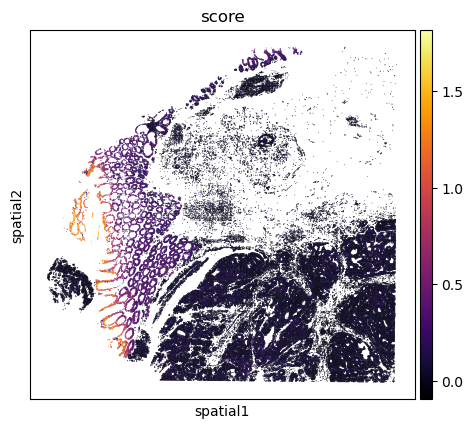

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)


cax = fig.axes[-1]


cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_entero.pdf", bbox_inches="tight")

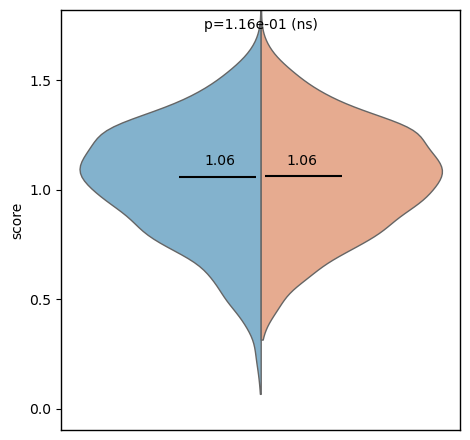

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_entero.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Endo (Endothelial)

In [ ]:
target_name = "Endothelial"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['VWF',
 'PECAM1',
 'ENG',
 'AQP1',
 'COL4A1',
 'COL4A2',
 'A2M',
 'VIM',
 'IGFBP7',
 'SPARC']

In [ ]:
mask_st = adata_stlens.obs["leiden_3.0"].astype(str) == "18"
mask_sc = adata_scanpy.obs["leiden_4.5"].astype(str) == "8"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/3735823523.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


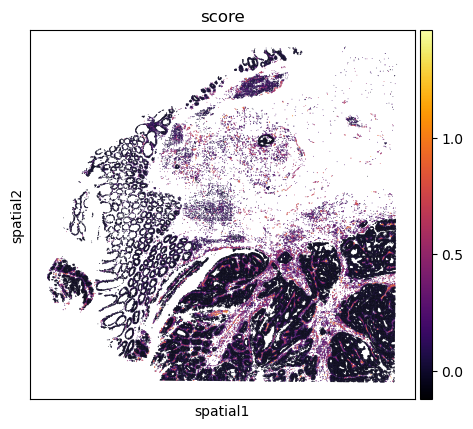

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)


cax = fig.axes[-1]


cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_endo.pdf", bbox_inches="tight")

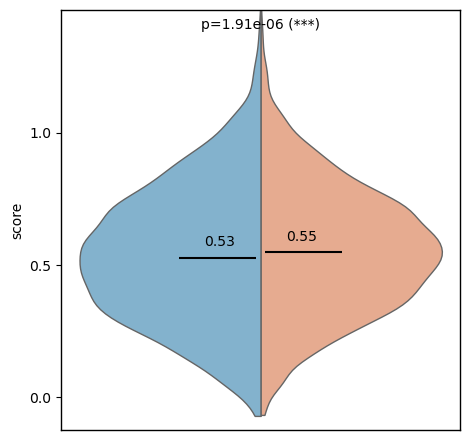

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_endo.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Macro (Macrophage)

In [ ]:
target_name = "Macrophage"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['APOE',
 'LYZ',
 'IFI30',
 'CD74',
 'PSAP',
 'CTSB',
 'VIM',
 'COL3A1',
 'TMSB4X',
 'MT-ND4']

In [ ]:
mask_st = adata_stlens.obs["leiden_1.5"].astype(str) == "11"
mask_sc = adata_scanpy.obs["leiden_3.0"].astype(str) == "21"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/1819424758.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


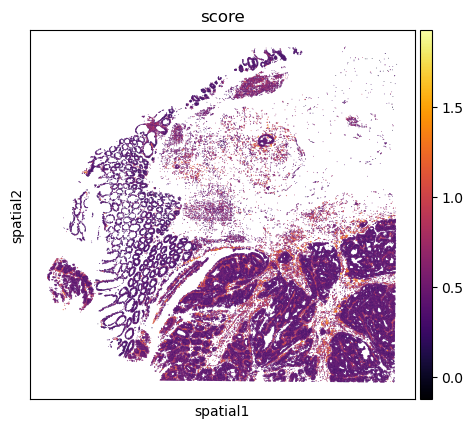

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)


cax = fig.axes[-1]


cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_macro.pdf", bbox_inches="tight")

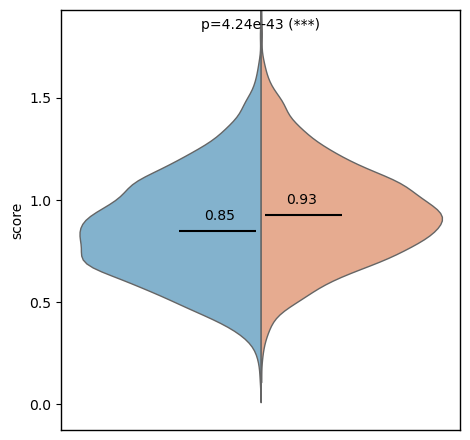

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_macro.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### ProImmune2 (Proliferating Immune II)

In [ ]:
target_name = "Proliferating Immune II"

top10 = top10_markers(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
top10_genes

['MT-CO3',
 'MT-CO2',
 'MT-ATP6',
 'IGKC',
 'MT-ND4',
 'MT-CYB',
 'MT-ND3',
 'MT-ND2',
 'MT-ND4L',
 'TSPAN8']

In [ ]:
mask_st = adata_stlens.obs["leiden_1.0"].astype(str) == "16"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "34"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2741272/3055806321.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


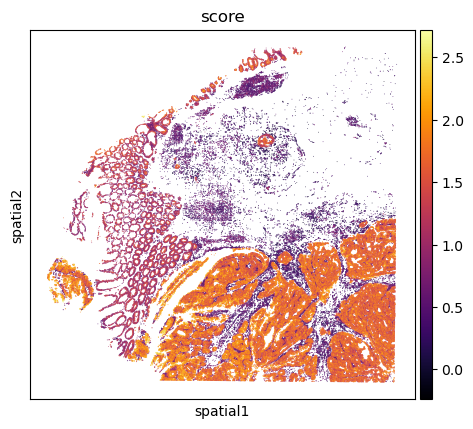

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)


cax = fig.axes[-1]


cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter_proimmune.pdf", bbox_inches="tight")

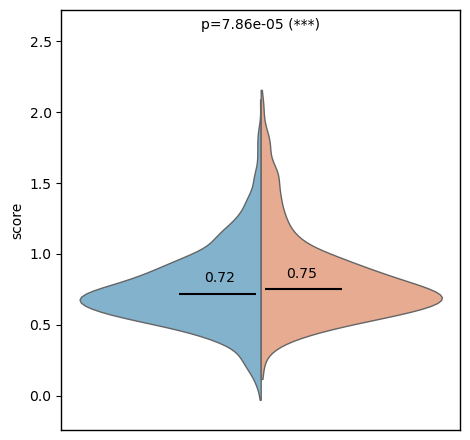

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)


ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/violin_proimmune.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Tumor

##### Tumor 1

In [ ]:
target_name = "Tumor I"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['IGKC',
 'MT-ND2',
 'TMSB4X',
 'KCNK3',
 'GRM3',
 'UGT1A5',
 'OR1D2',
 'SLC36A2',
 'SLC12A1',
 'CCDC160']

In [ ]:
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_1.pdf"


sc.pl.spatial(
    adata_stlens,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/4242284902.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


##### Tumor 2

In [ ]:
target_name = "Tumor II"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['DPEP1',
 'REG1A',
 'LY6G6D',
 'MUC17',
 'FGGY',
 'PRAP1',
 'KRT23',
 'ALDOB',
 'ANPEP',
 'DMBT1']

In [ ]:
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_2.pdf"


sc.pl.spatial(
    adata_stlens,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1483605772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


##### tumor 3

In [ ]:
target_name = "Tumor III"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['OLFM4',
 'CEACAM5',
 'COL3A1',
 'VIM',
 'MT-CYB',
 'B2M',
 'TMSB4X',
 'DMBT1',
 'REG1A',
 'COL1A1']

In [ ]:
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_3.pdf"


sc.pl.spatial(
    adata_stlens,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1418711188.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


##### tumor 4

In [ ]:
target_name = "Tumor IV"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['MT-ATP6',
 'MT-ND3',
 'IGKC',
 'MT-CYB',
 'MT-CO3',
 'MT-CO2',
 'IGHG1',
 'MT-ND2',
 'MT-ND1',
 'MT-ND4']

In [ ]:
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_4.pdf"


sc.pl.spatial(
    adata_stlens,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/1033028183.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


##### tumor 5

In [ ]:
target_name = "Tumor V"

top10 = top3_markers_temp(adata_stlens, groupby="DeconvolutionLabel1", target=target_name)

In [ ]:
top10_genes=top10.names.tolist()
top10_genes

['S100A6',
 'OLFM4',
 'KRT8',
 'TMSB4X',
 'CEACAM6',
 'CEACAM5',
 'PERP',
 'TGFBI',
 'IFI6',
 'ACTB']

In [ ]:
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
from pathlib import Path

outdir = Path("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation")
outfile = outdir / "tumor_5.pdf"


sc.pl.spatial(
    adata_stlens,
    color='score',
    spot_size=50,
    cmap='inferno',
    show=False
)

plt.savefig(outfile, format="pdf", bbox_inches="tight")
plt.close()

/tmp/ipykernel_3119142/3887060089.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


### Violin plot of correlation

In [ ]:
from sklearn.metrics import jaccard_score
import numpy as np
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)

summary_df_stlens = optimize_resolution_for_all_celltypes_jaccard(
    adata_stlens, 
    annotation_key = 'Faria de Oliveira et al.', 
    average = None)

Processing cell types: 100%|██████████| 33/33 [06:49<00:00, 12.42s/it]


In [ ]:
celltype_to_color = dict(zip(
    adata_stlens.obs['Faria de Oliveira et al.'].cat.categories,
    adata_stlens.uns['Faria de Oliveira et al._colors']
))

summary_df_stlens['colors'] = summary_df_stlens['cell_type'].map(celltype_to_color)

def unify_colors(group):
    max_color = group.loc[group['best_jaccard'].idxmax(), 'colors']
    group['colors'] = max_color
    return group

summary_df_stlens = summary_df_stlens.groupby(
    ['best_resolution', 'best_cluster'], group_keys=False
).apply(unify_colors)

/tmp/ipykernel_3306579/171875281.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(unify_colors)
/tmp/ipykernel_3306579/171875281.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(unify_colors)


     cell_type  n_intersection  n_stlens_only  n_chen_only  \
0       Tumor1              11           1895           26   
1       Tumor5             421           2908          688   
2       Entero            3223            243          331   
3        Macro            2000           5174          539   
4       Tumor3             184           5680          525   
5   ProImmune2             188           1918          299   
6       Tumor2           39306            222        60480   
7       Tumor4               1            283           16   
8       ProFib             498           1757         1293   
9       Goblet           20137           1190          671   
10        Endo            2974           1139         1453   

    median_stlens_only  median_chen_only  
0             0.379267          0.290236  
1             0.548268          0.484186  
2             0.474745          0.446738  
3             0.367796          0.332611  
4             0.468729          0.430921

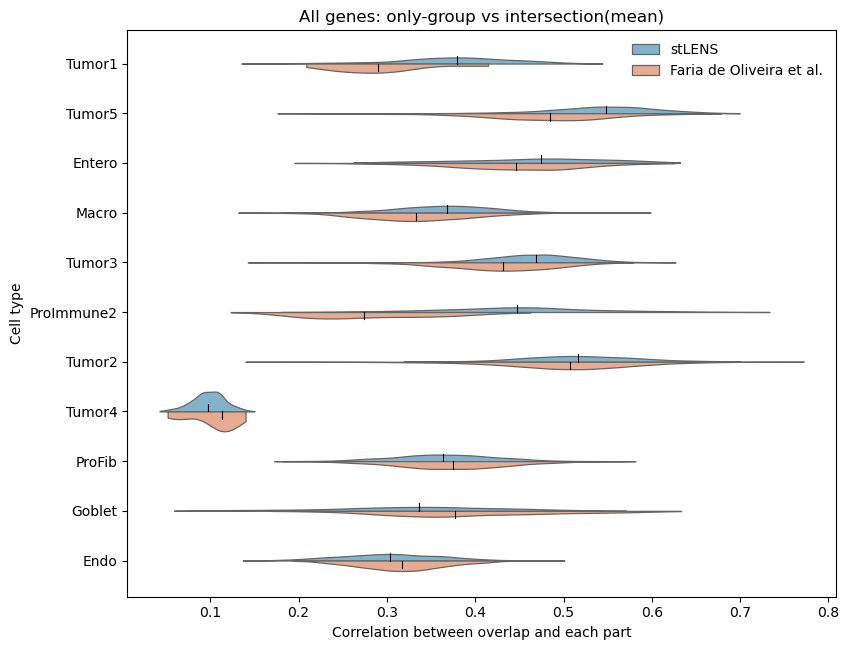

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

# 9개 cell type에 대해 all-gene 기반 correlation 분포를 하나의 violin plot으로 시각화
# NOTE: expression matrix is already log-transformed.
target_cell_types = [ 'Tumor1', 'Tumor5', 'Entero',  'Macro',
                      'Tumor3', 'ProImmune2', 'Tumor2', 'Tumor4','ProFib', 'Goblet', 'Endo',
]

all_genes = adata_stlens.var_names
n_genes = len(all_genes)


def to_1d(x):
    arr = np.asarray(x).ravel()
    return arr


def mean_vector(X):
    if sparse.issparse(X):
        return to_1d(X.mean(axis=0))
    return X.mean(axis=0)


def row_corr_to_ref_mean(X, ref_mean):
    """Row-wise Pearson corr between each row of X and dense ref_mean (ddof=0)."""
    g = ref_mean.shape[0]
    mr = float(ref_mean.mean())
    sr = float(ref_mean.std(ddof=0))
    if sr == 0:
        return np.full(X.shape[0], np.nan)

    if sparse.issparse(X):
        row_sum = to_1d(X.sum(axis=1))
        row_sq_sum = to_1d(X.power(2).sum(axis=1))
        dot = to_1d(X.dot(ref_mean))
    else:
        row_sum = X.sum(axis=1)
        row_sq_sum = (X ** 2).sum(axis=1)
        dot = X.dot(ref_mean)

    mx = row_sum / g
    varx = row_sq_sum / g - (mx ** 2)
    varx[varx < 0] = 0
    sx = np.sqrt(varx)

    cov = dot / g - mx * mr
    denom = sx * sr

    corr = np.full_like(cov, np.nan, dtype=float)
    valid = denom > 0
    corr[valid] = cov[valid] / denom[valid]
    return corr


rows = []
summary_rows = []

for ct in target_cell_types:
    if (summary_df_stlens['cell_type'] == ct).sum() == 0:
        print(f'[skip] {ct}: not found in summary_df_stlens')
        continue

    st_row = summary_df_stlens.loc[summary_df_stlens['cell_type'] == ct].iloc[0]
    st_key = f"leiden_{st_row['best_resolution']}"
    st_cluster = str(st_row['best_cluster'])

    mask_chen = adata_stlens.obs['Faria de Oliveira et al.'] == ct
    mask_st = adata_stlens.obs[st_key].astype(str) == st_cluster

    mask_inter = mask_chen & mask_st
    mask_st_only = (~mask_chen) & mask_st
    mask_chen_only = mask_chen & (~mask_st)

    n_inter = int(mask_inter.sum())
    n_st = int(mask_st_only.sum())
    n_chen = int(mask_chen_only.sum())

    if n_inter == 0 or n_st == 0 or n_chen == 0:
        print(f'[skip] {ct}: n_inter={n_inter}, n_st_only={n_st}, n_chen_only={n_chen}')
        continue

    X_inter = adata_stlens[mask_inter, all_genes].X
    X_st = adata_stlens[mask_st_only, all_genes].X
    X_chen = adata_stlens[mask_chen_only, all_genes].X

    ref_mean = mean_vector(X_inter)
    corr_st = row_corr_to_ref_mean(X_st, ref_mean)
    corr_chen = row_corr_to_ref_mean(X_chen, ref_mean)

    rows.append(pd.DataFrame({
        'cell_type': ct,
        'group': 'stLENS',
        'correlation': corr_st
    }))
    rows.append(pd.DataFrame({
        'cell_type': ct, 
        'group': 'Faria de Oliveira et al.',
        'correlation': corr_chen
    }))

    summary_rows.append({
        'cell_type': ct,
        'n_intersection': n_inter,
        'n_stlens_only': n_st,
        'n_chen_only': n_chen,
        'median_stlens_only': float(np.nanmedian(corr_st)),
        'median_chen_only': float(np.nanmedian(corr_chen)),
    })

plot_df = pd.concat(rows, ignore_index=True).dropna()
summary_df = pd.DataFrame(summary_rows)

print(summary_df)

# plot order: keep requested order but only cell types with computed rows
valid_order = [ct for ct in target_cell_types if ct in plot_df['cell_type'].unique()]

plt.figure(figsize=(8.6, 6.6))
ax = sns.violinplot(
    data=plot_df,
    y='cell_type',
    x='correlation',
    hue='group',
    order=valid_order,
    hue_order=['stLENS', 'Faria de Oliveira et al.'],
    palette={
        'stLENS': '#77b5d9',
        'Faria de Oliveira et al.': '#f4a582',
    },
    split=True,
    orient='h',
    inner=None,
    cut=0,
    linewidth=0.9,
)

# median 선 표시
for i, ct in enumerate(valid_order):
    for j, group in enumerate(['stLENS', 'Faria de Oliveira et al.']):
        subset = plot_df[(plot_df['cell_type'] == ct) & (plot_df['group'] == group)]
        if len(subset) == 0:
            continue
        med = subset['correlation'].median()
        if j == 0:  # 위쪽 반
            ax.plot([med, med], [i - 0.15, i], color='black', linewidth=0.8)
        else:        # 아래쪽 반
            ax.plot([med, med], [i, i + 0.15], color='black', linewidth=0.8)

ax.set_xlabel('Correlation between overlap and each part')
ax.set_ylabel('Cell type')
ax.set_title('All genes: only-group vs intersection(mean)')
ax.legend(title='', loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("/bce/groups/pnucolab/analysis/scLENS/output/visiumhd/validation2/jaccard_concordance.pdf", format="pdf", bbox_inches="tight")
plt.show()

## STOmics

In [ ]:
from stLENS import stLENS
stlens = stLENS()

### Load data

In [ ]:
import scanpy as sc

adata_stlens = sc.read_h5ad('./output/stomics/stlens_adata')
adata_scanpy = sc.read_h5ad('./output/stomics/scanpy_adata')

In [ ]:
# normalization 

sc.pp.normalize_total(adata_stlens)
sc.pp.log1p(adata_stlens)

### DEA

In [ ]:
import scanpy as sc

def top10_markers(adata, groupby, target, method="wilcoxon", key="deg"):
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=[target],
        reference="rest",
        method=method,
        use_raw=False,     
        key_added=key,
    )
    df = sc.get.rank_genes_groups_df(adata, group=target, key=key)
    df = df.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False])
    return df[["names", "logfoldchanges", "pvals_adj", "scores"]].head(10)

#### Ctx/Hip (Cortical or hippocampal glutamatergic neuron)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Cortical or hippocampal glutamatergic neuron")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_1.0"].astype(str) == "4"
mask_sc = adata_scanpy.obs["leiden_4.0"].astype(str) == "9"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2041856923.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


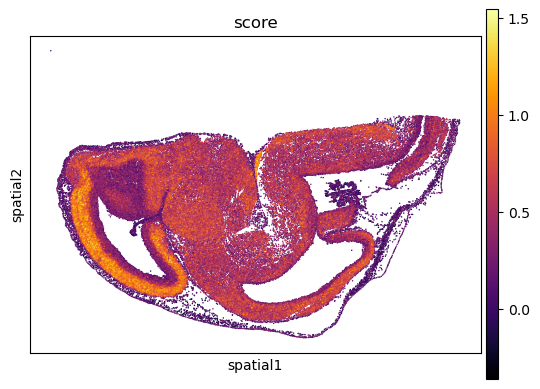

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter1.pdf", bbox_inches="tight")

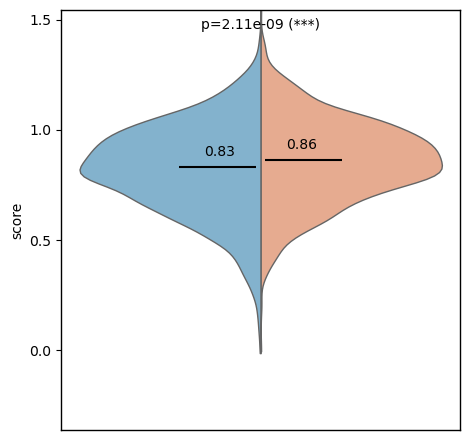

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin1.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### FB RG (Forebrain radial glia)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Forebrain radial glia")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "2"
mask_sc = adata_scanpy.obs["leiden_1.5"].astype(str) == "2"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/4138039861.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


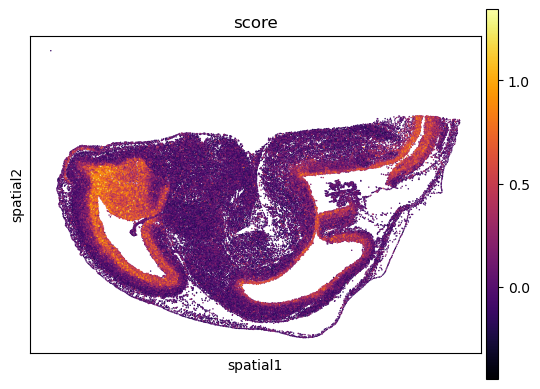

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter2.pdf", bbox_inches="tight")

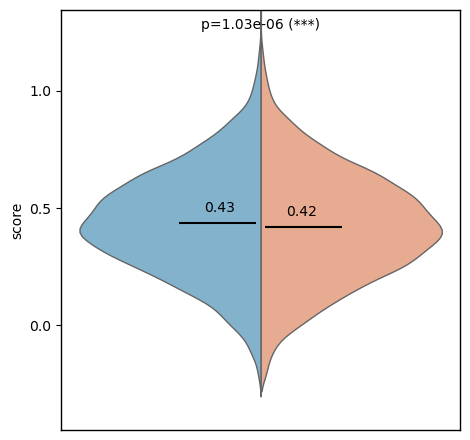

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin2.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Ctx IP (Cortical intermediate progenitor)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Cortical intermediate progenitor")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_4.0"].astype(str) == "6"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "5"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/155313628.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


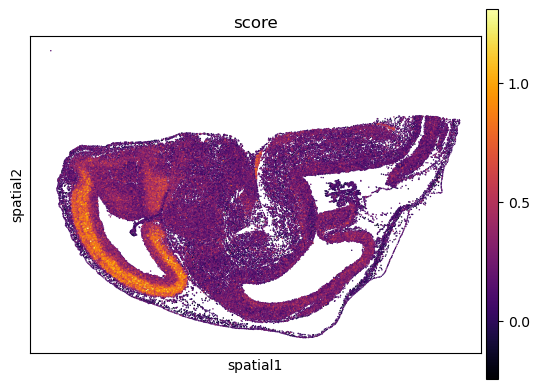

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter3.pdf", bbox_inches="tight")

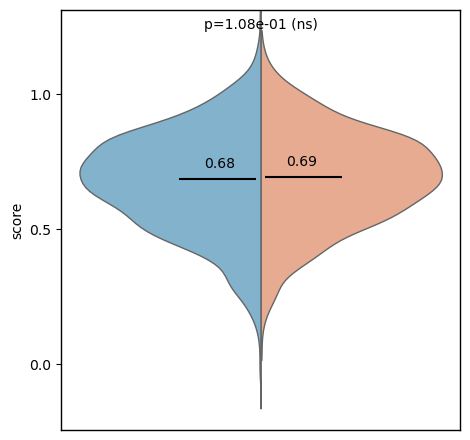

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin3.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### FB (Fibroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Fibroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "5"
mask_sc = adata_scanpy.obs["leiden_3.0"].astype(str) == "2"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2868874372.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


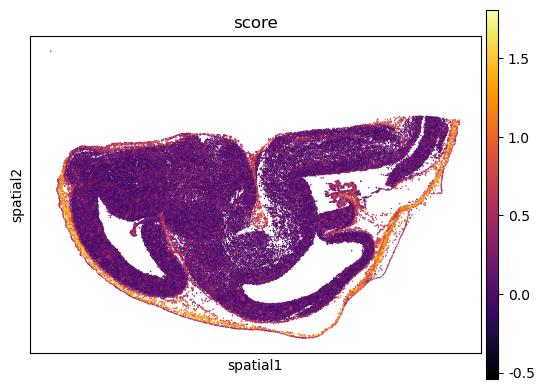

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter4.pdf", bbox_inches="tight")

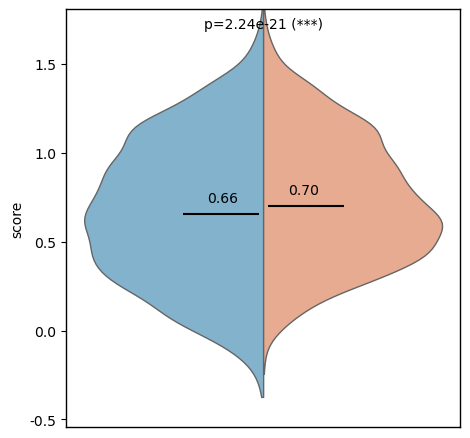

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin4.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB Glu NB (Hindbrain glutamatergic neuroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain glutamatergic neuroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_5.0"].astype(str) == "48"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "24"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/3087718920.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


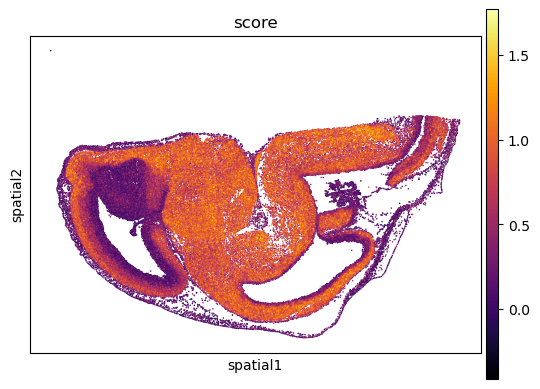

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter5.pdf", bbox_inches="tight")

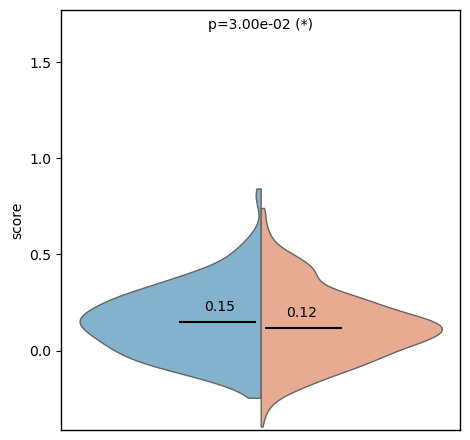

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin5.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB NB (Hindbrain neuroblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain neuroblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_3.5"].astype(str) == "0"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "4"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/1641073823.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


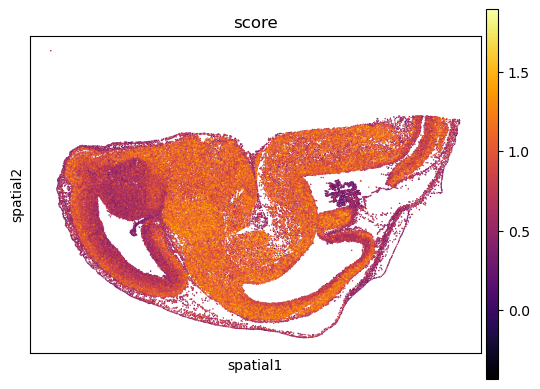

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter6.pdf", bbox_inches="tight")

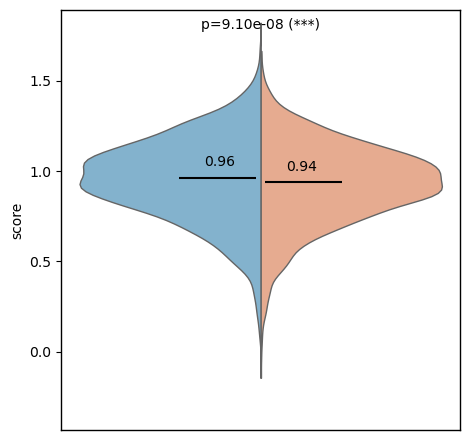

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin6.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### HB GB (Hindbrain glioblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Hindbrain glioblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_2.0"].astype(str) == "14"
mask_sc = adata_scanpy.obs["leiden_5.0"].astype(str) == "13"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/2538700838.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


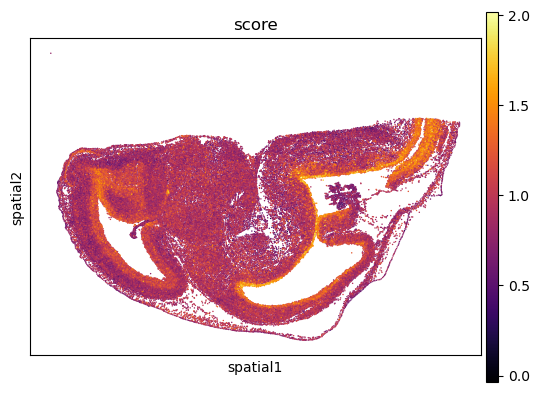

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter7.pdf", bbox_inches="tight")

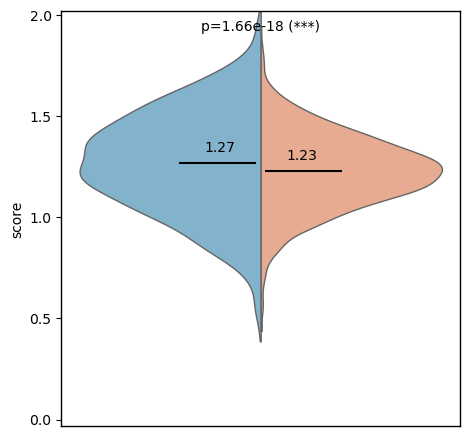

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin7.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### Mixed GB (Mixed region glioblast)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Mixed region glioblast")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_0.5"].astype(str) == "9"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "6"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/1007084332.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


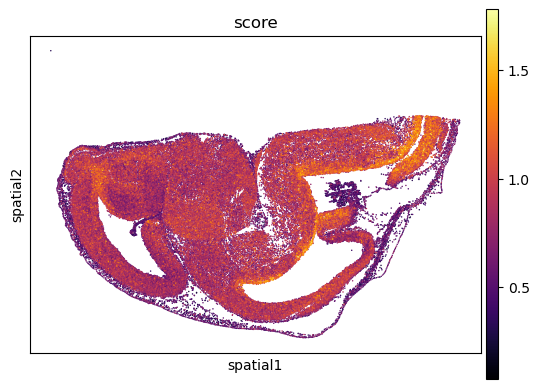

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter8.pdf", bbox_inches="tight")

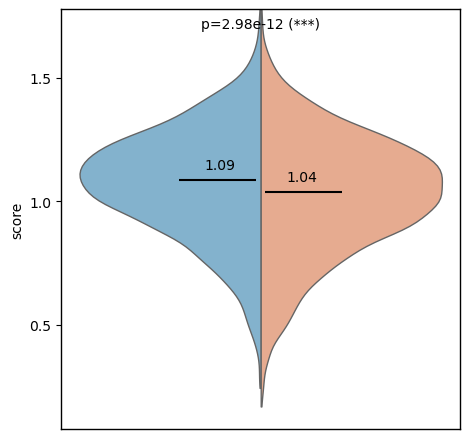

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin8.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


#### RBC (Erythrocyte)

In [ ]:
top10 = top10_markers(adata_stlens, groupby="annotation", target="Erythrocyte")

In [ ]:
top10_genes= top10.names.tolist()
sc.tl.score_genes(adata_stlens, gene_list = top10_genes)

In [ ]:
mask_st = adata_stlens.obs["leiden_1.0"].astype(str) == "12"
mask_sc = adata_scanpy.obs["leiden_1.0"].astype(str) == "7"

score_st = adata_stlens[mask_st].obs['score']
score_sc = adata_stlens[mask_sc].obs['score']

/tmp/ipykernel_2715108/703870670.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


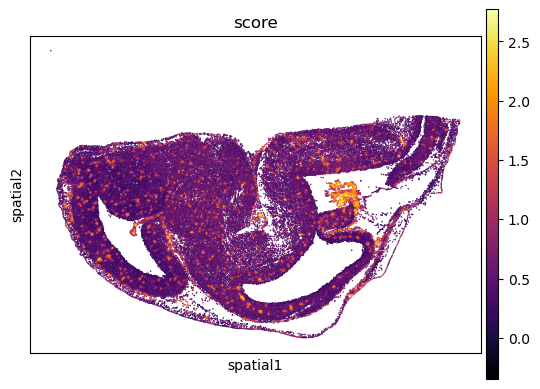

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.ticker as mticker

score_all = adata_stlens.obs["score"].to_numpy()
vmax = np.nanmax(score_all)
vmin = np.nanmin(score_all)

sc.settings.figdir = "./output/stomics/validation"

fig = sc.pl.spatial(
    adata_stlens,
    color="score",
    spot_size=50,
    cmap="inferno",
    vmax=vmax,
    vmin=vmin,
    show=False,
    return_fig=True,   
)

cax = fig.axes[-1]

cax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
cax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

fig.savefig(f"{sc.settings.figdir}/scatter9.pdf", bbox_inches="tight")

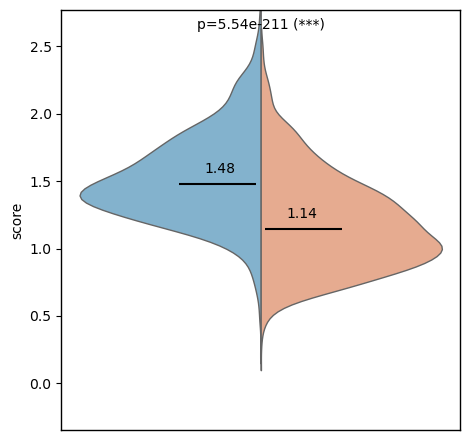

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import ks_2samp

def p_to_star(p):
    if not np.isfinite(p):
        return "NA"
    if p > 0.05:
        return "ns"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"

score_all = adata_stlens.obs["score"].to_numpy()
ymin = np.nanmin(score_all)
ymax = np.nanmax(score_all)

score_st = np.asarray(score_st)
score_sc = np.asarray(score_sc)

df = pd.DataFrame({
    "score": np.concatenate([score_st, score_sc]),
    "method": (["stLENS"] * len(score_st)) + (["Scanpy"] * len(score_sc)),
    "x": [""] * (len(score_st) + len(score_sc)),
})

ks = ks_2samp(score_st, score_sc)
p = ks.pvalue
star = p_to_star(p)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
sns.violinplot(
    data=df,
    x="x",
    y="score",
    hue="method",
    hue_order=["stLENS", "Scanpy"],
    split=True,
    cut=0,
    inner=None,
    palette={"stLENS": "#77b5d9", "Scanpy": "#f4a582"},
    linewidth=1,
    ax=ax
)

ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.set_xlabel("")
ax.set_xticks([])
ax.set_title("")

y_text = ymax - 0.02 * (ymax - ymin)
ax.text(0, y_text, f"p={p:.2e} ({star})", ha="center", va="top")

med_st = float(np.nanmedian(score_st))
med_sc = float(np.nanmedian(score_sc))

x_center = 0.0
half_width = 0.18
gap = 0.01

ax.hlines(med_st, x_center - half_width, x_center - gap, colors="k", linewidth=1.5, zorder=5)
ax.hlines(med_sc, x_center + gap, x_center + half_width, colors="k", linewidth=1.5, zorder=5)

dy = 0.02 * (ymax - ymin)
ax.text(x_center - half_width/2, med_st + dy, f"{med_st:.2f}", ha="center", va="bottom", fontsize=10)
ax.text(x_center + half_width/2, med_sc + dy, f"{med_sc:.2f}", ha="center", va="bottom", fontsize=10)

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.0)

fig.tight_layout()
pdf_path = "./output/stomics/validation/violin9.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()


### Violin plot of correlation

In [ ]:
from sklearn.metrics import jaccard_score
import numpy as np
import pandas as pd
from tqdm import tqdm

def optimize_resolution_for_all_celltypes_jaccard(
    adata,
    average,
    annotation_key='annotation',
    res_range=np.arange(0.5, 5.1, 0.5)
):
    summary = []
    cell_types = adata.obs[annotation_key].cat.categories

    for cell_type in tqdm(cell_types, desc="Processing cell types"):
        jaccard_scores = []
        best_clusters = []
        resolutions_checked = []

        gt_mask = adata.obs[annotation_key] == cell_type
        if gt_mask.sum() == 0:
            continue

        for res in res_range:
            leiden_key = f"leiden_{res:.1f}"
            if leiden_key not in adata.obs.columns:
                continue
            
            cluster_names = adata.obs[leiden_key].cat.categories
            best_jaccard = -1
            best_cluster = None

            for cluster in cluster_names:
                pred_mask = adata.obs[leiden_key] == cluster

                _, score = jaccard_score(gt_mask, pred_mask, average=average)
                if score > best_jaccard:
                    best_jaccard = score
                    best_cluster = cluster

            jaccard_scores.append(best_jaccard)
            best_clusters.append(best_cluster)
            resolutions_checked.append(res)

        df = pd.DataFrame({
            'resolution': resolutions_checked,
            'jaccard': jaccard_scores,
            'best_cluster': best_clusters
        })

        best_idx = df['jaccard'].idxmax()
        best_row = df.loc[best_idx]
        summary.append({
            'cell_type': cell_type,
            'best_resolution': best_row['resolution'],
            'best_cluster': best_row['best_cluster'],
            'best_jaccard': best_row['jaccard']
        })

    return pd.DataFrame(summary)

summary_df_stlens = optimize_resolution_for_all_celltypes_jaccard(
    adata_stlens, 
    annotation_key = 'Chen et al.', 
    average = None)


Processing cell types: 100%|██████████| 33/33 [06:49<00:00, 12.42s/it]


In [ ]:
celltype_to_color = dict(zip(
    adata_stlens.obs['Chen et al.'].cat.categories,
    adata_stlens.uns['Chen et al._colors']
))

summary_df_stlens['colors'] = summary_df_stlens['cell_type'].map(celltype_to_color)

def unify_colors(group):
    max_color = group.loc[group['best_jaccard'].idxmax(), 'colors']
    group['colors'] = max_color
    return group

summary_df_stlens = summary_df_stlens.groupby(
    ['best_resolution', 'best_cluster'], group_keys=False
).apply(unify_colors)

/tmp/ipykernel_3306579/171875281.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(unify_colors)
/tmp/ipykernel_3306579/171875281.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(unify_colors)


            cell_type  n_intersection  n_stlens_only  n_chen_only  \
0                  FB            3461           1789          801   
1           HB Glu NB              16            317          323   
2  Ctx/Hip Glu neuron             892           4293          288   
3               HB GB             199           1669          183   
4                 RBC            2062             54         3702   
5               FB RG            4020           4685          443   
6               HB NB             956           2670         1764   
7              Ctx IP             966           1527          339   
8            Mixed GB            1178           1228         1344   

   median_stlens_only  median_chen_only  
0            0.519577          0.511510  
1            0.524927          0.440168  
2            0.578141          0.505117  
3            0.505873          0.489928  
4            0.548364          0.512121  
5            0.533668          0.502562  
6            0.

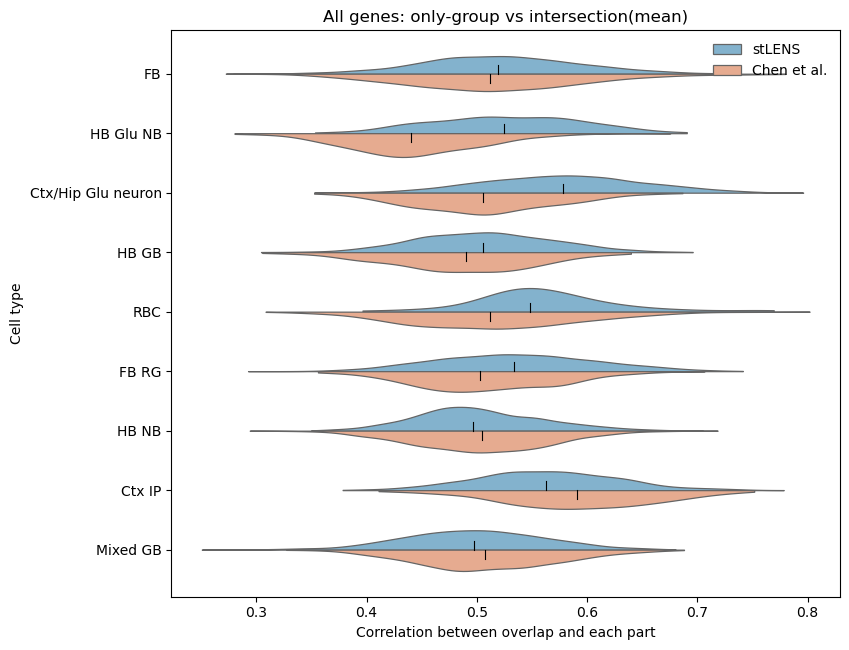

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

# 9개 cell type에 대해 all-gene 기반 correlation 분포를 하나의 violin plot으로 시각화
# NOTE: expression matrix is already log-transformed.
target_cell_types = [
    'FB', 'HB Glu NB', 'Ctx/Hip Glu neuron','HB GB','RBC',
    'FB RG', 'HB NB', 'Ctx IP', 'Mixed GB'
]

all_genes = adata_stlens.var_names
n_genes = len(all_genes)


def to_1d(x):
    arr = np.asarray(x).ravel()
    return arr


def mean_vector(X):
    if sparse.issparse(X):
        return to_1d(X.mean(axis=0))
    return X.mean(axis=0)


def row_corr_to_ref_mean(X, ref_mean):
    """Row-wise Pearson corr between each row of X and dense ref_mean (ddof=0)."""
    g = ref_mean.shape[0]
    mr = float(ref_mean.mean())
    sr = float(ref_mean.std(ddof=0))
    if sr == 0:
        return np.full(X.shape[0], np.nan)

    if sparse.issparse(X):
        row_sum = to_1d(X.sum(axis=1))
        row_sq_sum = to_1d(X.power(2).sum(axis=1))
        dot = to_1d(X.dot(ref_mean))
    else:
        row_sum = X.sum(axis=1)
        row_sq_sum = (X ** 2).sum(axis=1)
        dot = X.dot(ref_mean)

    mx = row_sum / g
    varx = row_sq_sum / g - (mx ** 2)
    varx[varx < 0] = 0
    sx = np.sqrt(varx)

    cov = dot / g - mx * mr
    denom = sx * sr

    corr = np.full_like(cov, np.nan, dtype=float)
    valid = denom > 0
    corr[valid] = cov[valid] / denom[valid]
    return corr


rows = []
summary_rows = []

for ct in target_cell_types:
    if (summary_df_stlens['cell_type'] == ct).sum() == 0:
        print(f'[skip] {ct}: not found in summary_df_stlens')
        continue

    st_row = summary_df_stlens.loc[summary_df_stlens['cell_type'] == ct].iloc[0]
    st_key = f"leiden_{st_row['best_resolution']}"
    st_cluster = str(st_row['best_cluster'])

    mask_chen = adata_stlens.obs['Chen et al.'] == ct
    mask_st = adata_stlens.obs[st_key].astype(str) == st_cluster

    mask_inter = mask_chen & mask_st
    mask_st_only = (~mask_chen) & mask_st
    mask_chen_only = mask_chen & (~mask_st)

    n_inter = int(mask_inter.sum())
    n_st = int(mask_st_only.sum())
    n_chen = int(mask_chen_only.sum())

    if n_inter == 0 or n_st == 0 or n_chen == 0:
        print(f'[skip] {ct}: n_inter={n_inter}, n_st_only={n_st}, n_chen_only={n_chen}')
        continue

    X_inter = adata_stlens[mask_inter, all_genes].X
    X_st = adata_stlens[mask_st_only, all_genes].X
    X_chen = adata_stlens[mask_chen_only, all_genes].X

    ref_mean = mean_vector(X_inter)
    corr_st = row_corr_to_ref_mean(X_st, ref_mean)
    corr_chen = row_corr_to_ref_mean(X_chen, ref_mean)

    rows.append(pd.DataFrame({
        'cell_type': ct,
        'group': 'stLENS',
        'correlation': corr_st
    }))
    rows.append(pd.DataFrame({
        'cell_type': ct,
        'group': 'Chen et al.',
        'correlation': corr_chen
    }))

    summary_rows.append({
        'cell_type': ct,
        'n_intersection': n_inter,
        'n_stlens_only': n_st,
        'n_chen_only': n_chen,
        'median_stlens_only': float(np.nanmedian(corr_st)),
        'median_chen_only': float(np.nanmedian(corr_chen)),
    })

plot_df = pd.concat(rows, ignore_index=True).dropna()
summary_df = pd.DataFrame(summary_rows)

print(summary_df)

# plot order: keep requested order but only cell types with computed rows
valid_order = [ct for ct in target_cell_types if ct in plot_df['cell_type'].unique()]

plt.figure(figsize=(8.6, 6.6))
ax = sns.violinplot(
    data=plot_df,
    y='cell_type',
    x='correlation',
    hue='group',
    order=valid_order,
    hue_order=['stLENS', 'Chen et al.'],
    palette={
        'stLENS': '#77b5d9',
        'Chen et al.': '#f4a582',
    },
    split=True,
    orient='h',
    inner=None,
    cut=0,
    linewidth=0.9,
)

# median 선 표시
for i, ct in enumerate(valid_order):
    for j, group in enumerate(['stLENS', 'Chen et al.']):
        subset = plot_df[(plot_df['cell_type'] == ct) & (plot_df['group'] == group)]
        if len(subset) == 0:
            continue
        med = subset['correlation'].median()
        if j == 0:  # 위쪽 반
            ax.plot([med, med], [i - 0.15, i], color='black', linewidth=0.8)
        else:        # 아래쪽 반
            ax.plot([med, med], [i, i + 0.15], color='black', linewidth=0.8)



ax.set_xlabel('Correlation between overlap and each part')
ax.set_ylabel('Cell type')
ax.set_title('All genes: only-group vs intersection(mean)')
ax.legend(title='', loc='upper right', frameon=False)

plt.tight_layout()
plt.show()
